In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ctx = 'c600'
base_results_path = f'../../../results/PlantCAD2_tasks/maize_cell_type_accessible_{ctx}/'
labels_file = os.path.join(base_results_path, 'test.tsv')
labels = pd.read_csv(labels_file, sep='\t')
y_true = np.array([list(map(int, s)) for s in labels['Label']])

In [3]:
model_names = [
    'agront-checkpoints-lr-1e-4',
    'cnn-lstm-imbalance-lr-1e-3',
    '2nd_pcv2-l24-d0768-checkpoints-lr-1e-4',
    '2nd_pcv2-l48-d1024-checkpoints-lr-1e-4',
    '2nd_pcv2-l48-d1536-checkpoints-lr-1e-4',
    'sup_pcv2-l24-d0768-checkpoints-lr-1e-4',
]

In [4]:
all_results = []

print("\nStarting PRAUC calculation for each model...")
for model_name in model_names:
    preds_file = os.path.join(base_results_path, model_name, 'test_predictions.tsv')

    if not os.path.exists(preds_file):
        print(f"  - WARNING: Predictions for model '{model_name}' not found. Skipping.")
        continue

    print(f"  - Processing model: {model_name}")
    preds = pd.read_csv(preds_file)
    y_scores = preds.values

    # Basic validation
    if y_true.shape != y_scores.shape:
        print(f"    - ERROR: Shape mismatch for model {model_name}. Labels: {y_true.shape}, Preds: {y_scores.shape}. Skipping.")
        continue

    # Calculate PRAUC for each label (i.e., each column)
    num_labels = y_true.shape[1]
    for i in range(num_labels):
        # The metric is only defined for classes with at least one positive sample
        if np.sum(y_true[:, i]) > 0:
            prauc = average_precision_score(y_true[:, i], y_scores[:, i])
            all_results.append({'Model': model_name, 'PRAUC': prauc})


Starting PRAUC calculation for each model...
  - Processing model: agront-checkpoints-lr-1e-4
  - Processing model: cnn-lstm-imbalance-lr-1e-3
  - Processing model: 2nd_pcv2-l24-d0768-checkpoints-lr-1e-4
  - Processing model: 2nd_pcv2-l48-d1024-checkpoints-lr-1e-4
  - Processing model: 2nd_pcv2-l48-d1536-checkpoints-lr-1e-4
  - Processing model: sup_pcv2-l24-d0768-checkpoints-lr-1e-4


In [5]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(f"{ctx}_PRAUC.tsv", sep='\t', index=False)

In [6]:
results_df['Model'] = results_df['Model'].str.replace('-checkpoints-lr-1e-4', '', regex=False)
results_df['Model'] = results_df['Model'].str.replace('-imbalance-lr-1e-3', '', regex=False)
stat = results_df.groupby('Model')['PRAUC'].median()
stat.to_csv(f"{ctx}_PRAUC_Median.tsv", sep='\t', index=True)

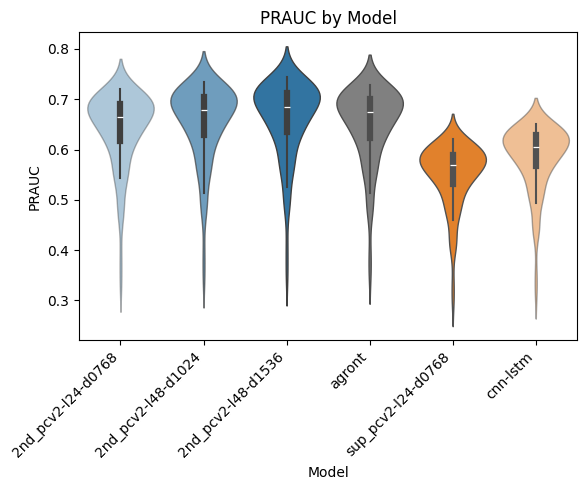

In [9]:
plt.figure(figsize=(6, 5))
pcv2_alphas = [0.4, 0.7, 1.0]

# Define palette with RGBA colors
custom_palette = {
    '2nd_pcv2-l24-d0768': 'C0',
    '2nd_pcv2-l48-d1024': 'C0',
    '2nd_pcv2-l48-d1536': 'C0',
    'agront': 'gray',
    'sup_pcv2-l24-d0768': 'C1',
    'cnn-lstm': 'C1'
}

model_order = [
    '2nd_pcv2-l24-d0768',
    '2nd_pcv2-l48-d1024',
    '2nd_pcv2-l48-d1536',
    'agront',
    'sup_pcv2-l24-d0768',
    'cnn-lstm'
]

for idx, model in enumerate(model_order):
    subset = results_df[results_df['Model'] == model]
    if 'cnn' in model:
        alpha = 0.5
    elif 'sup_pcv2' not in model and 'pcv2' in model:
        alpha = pcv2_alphas[idx]
    else:
        alpha = 1
        
    color = custom_palette[model]

    sns.violinplot(
        x='Model',
        y='PRAUC',
        data=subset,
        inner='box',
        color=color,
        linewidth=1,
        alpha=alpha
    )

plt.xticks(rotation=45, ha='right')
plt.title('PRAUC by Model')
plt.tight_layout()
plt.savefig(f'{ctx}_PRAUC.pdf', format='pdf', bbox_inches='tight')
plt.show()